# Phase 3 — Final Results: Multimodal Land Cover Segmentation

## Research Question

> *Does conditioning a segmentation transformer on AI-generated scene descriptions improve land cover segmentation accuracy compared to an image-only baseline?*

## What This Notebook Does

This notebook extends Phase 2

TBD


Colab was using to run this notebook, L4 GPU was used.

Due to code changes and Colab's session duration limitations, this notebook does not contain the direct results of every experiment. In other words, the experiments were run in different notebook versions. As proof of this, you can see the experiments and their results in the weight and bias section; their names are:
- baseline-mit-b0
- fused-gemma
- fused-qwen
- fused-b1-gemma
- fused-b2-gemma
- baseline-mit-b1
- baseline-mit-b2
- fused-b0-random-caption

In [1]:
#!pip install -q torch torchvision transformers accelerate evaluate
!pip install -q pillow matplotlib seaborn scikit-learn pandas numpy pyyaml
!pip install -q wandb
!pip install -q torch torchvision transformers==4.37.2 accelerate evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 150.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.


In [2]:
!nvidia-smi

Sat Jun  6 20:04:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   58C    P8             17W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import wandb
wandb.login(key='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')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ftmoztl to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
import os
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
    BertModel,
    BertTokenizer,
)
import wandb

warnings.filterwarnings('ignore')
print('All imports successful.')
print(f'PyTorch version: {torch.__version__}')


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

All imports successful.
PyTorch version: 2.11.0+cu128


In [6]:
# CONFIG
# Re-run with a different CONFIG
# Each experiment logged to W&B under a new run name
CONFIG = {
    # Experiment
    'run_name':          'baseline-mit-b0',   # descriptive name logged to W&B
    'caption_col':       None,                # None=image-only - 'vision_gemma3-4b' - 'vision_qwen3-vl-8b'

    # Data
    'image_size':        512,
    'batch_size':        4,
    'seed':              42,

    # Model
    # Backbone options: nvidia/mit-b0 (3.7M), mit-b1 (14M), mit-b2 (27M) and so on.
    'backbone':          'nvidia/mit-b0',
    'text_model':        'bert-base-uncased',
    'freeze_bert':       True,    # unfreeze as Phase 3 ablation
    'num_classes':       7,

    # Phase 3 fusion settings
    # fusion_stage: which SegFormer encoder stage to inject text into (0-indexed, 0=H/4 … 3=H/32)
    # Default 3 = last stage (matches Phase 2 behaviour for backward compatibility)
    'fusion_stage':          3,
    # unfreeze_bert_layers: number of last BERT encoder layers to unfreeze (0 = fully frozen)
    'unfreeze_bert_layers':  0,
    # fusion_hidden_dim: projection dimension inside CrossAttentionFusion
    'fusion_hidden_dim':     256,

    # Training
    'num_epochs':        20,
    'learning_rate':     6e-5,
    'weight_decay':      0.01,
    'grad_accumulation': 2,      # effective batch size = batch_size x grad_accumulation = 8
    # Important NOTE: class-weighted loss addresses the dominant-class prediction
    # problem identified in Phase 1 — the model was covering the whole image with
    # the most frequent class to minimise plain cross-entropy.
    # We need to careful about it by using class weights
    'use_class_weights': True,
    # fp16 mixed precision: only enabled on CUDA
    'mixed_precision':   True,

    # W&B
    'use_wandb':         True,
    'wandb_project':     'multimodal-landcover-segmentation',
    'wandb_entity':      'ftmoztl',

    # Save checkpoints
    'save_dir':          (
        '/content/drive/MyDrive/multimodal-landcover-segmentation/checkpoints'
        if os.path.exists('/content/drive/MyDrive')
        else 'checkpoints'
    ),
    'save_best':         True,   # save checkpoint when val mIoU improves
}

# Per-stage channel dimensions for each backbone
# MiT encoder produces 4 feature maps; index = stage (0=H/4, 1=H/8, 2=H/16, 3=H/32)
BACKBONE_STAGE_CHANNELS = {
    'nvidia/mit-b0': [32,  64,  160, 256],
    'nvidia/mit-b1': [64,  128, 320, 512],
    'nvidia/mit-b2': [64,  128, 320, 512],
    'nvidia/mit-b3': [64,  128, 320, 512],
    'nvidia/mit-b4': [64,  128, 320, 512],
    'nvidia/mit-b5': [64,  128, 320, 512],
}

# Kept for backward compatibility with Phase 2 load cells
BACKBONE_CHANNELS = {k: v[-1] for k, v in BACKBONE_STAGE_CHANNELS.items()}

FAIR_CAPTION_COLS = ['vision_gemma3-4b', 'vision_qwen3-vl-8b']


def get_device():
    """
    I'm Macbook user BUT: MPS (Apple Silicon) crashes during SegFormer backprop due to a
    known non-contiguous tensor bug in the autograd engine. CPU is used on macOS.
    Colab use CUDA and are not affected.
    """
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif platform.system() == 'Darwin':
        return torch.device('cpu')  # MPS incompatible with SegFormer backward
    return torch.device('cpu')


device = get_device()
# num_workers=0 for MAcbook, 2 for Colab
NUM_WORKERS = 0 if platform.system() == 'Darwin' else 2

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

print(f'Device      : {device}')
print(f'num_workers : {NUM_WORKERS}')
print(f'Backbone    : {CONFIG["backbone"]}')
print(f'caption_col : {CONFIG["caption_col"]}')
print(f'save_dir    : {CONFIG["save_dir"]}')


Device      : cuda
num_workers : 2
Backbone    : nvidia/mit-b0
caption_col : None
save_dir    : /content/drive/MyDrive/multimodal-landcover-segmentation/checkpoints


In [7]:
CLASS_INFO = {
    0: {'name': 'Tree',     'color': (0,   100, 0)},
    1: {'name': 'Shrub',    'color': (255, 182, 193)},
    2: {'name': 'Grass',    'color': (154, 205, 50)},
    3: {'name': 'Crop',     'color': (255, 215, 0)},
    4: {'name': 'Built-up', 'color': (139, 69,  19)},
    5: {'name': 'Barren',   'color': (211, 211, 211)},
    6: {'name': 'Water',    'color': (0,   0,   255)},
}
CLASS_COLORS = {info['color']: idx for idx, info in CLASS_INFO.items()}
CLASS_NAMES  = [CLASS_INFO[i]['name'] for i in range(len(CLASS_INFO))]
id2label     = {idx: info['name'] for idx, info in CLASS_INFO.items()}
label2id     = {info['name']: idx for idx, info in CLASS_INFO.items()}
print('Classes:', CLASS_NAMES)


Classes: ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']


## 1. Data Pipeline

Dataset exploration was completed in Phase 1 and is not repeated here. I load the full 10,000-sample
dataset, apply a seeded 80/10/10 split in memory, and compute inverse-frequency class weights to
address the dominant-class prediction problem noted by the Phase 1 reviewer.


In [8]:
for _c in [
    '/content/drive/MyDrive/multimodal-landcover-segmentation/data',
    'data',
    '../data',
]:
    if os.path.exists(os.path.join(_c, 'captions.csv')):
        DATA_DIR = _c
        break
else:
    DATA_DIR = 'data'

IMAGES_DIR   = os.path.join(DATA_DIR, 'images')
MASKS_DIR    = os.path.join(DATA_DIR, 'masks')
CAPTIONS_CSV = os.path.join(DATA_DIR, 'captions.csv')
print(f'Data directory: {os.path.abspath(DATA_DIR)}')


def normalise_filename(fn_raw):
    """Ensure filename ends with .png — works for any digit count."""
    fn = str(fn_raw).strip()
    return fn if fn.endswith('.png') else fn + '.png'


def rgb_mask_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    """Convert RGB mask (H, W, 3) to class index mask (H, W) using vectorised NumPy."""
    class_mask = np.zeros(mask_rgb.shape[:2], dtype=np.int64)
    for color, class_idx in CLASS_COLORS.items():
        class_mask[np.all(mask_rgb == np.array(color, dtype=np.uint8), axis=-1)] = class_idx
    return class_mask


def class_mask_to_rgb(class_mask: np.ndarray) -> np.ndarray:
    """Convert class index mask back to RGB for visualization."""
    rgb = np.zeros((*class_mask.shape, 3), dtype=np.uint8)
    for idx in range(len(CLASS_INFO)):
        rgb[class_mask == idx] = CLASS_INFO[idx]['color']
    return rgb


Data directory: /content/drive/MyDrive/multimodal-landcover-segmentation/data


In [9]:
class LandCoverDataset(Dataset):
    """
    Designed this dataset class to handle the three-way correspondence between
    satellite images, segmentation masks, and (optionally) text captions.
    Setting caption_col=None gives the image-only baseline DataLoader;
    setting it to a column name gives the fused model DataLoader.
    """

    def __init__(self, df, images_dir, masks_dir, processor,
                 caption_col=None, image_size=512):
        """
        Args:
            df:          DataFrame subset (already filtered by split)
            images_dir:  path to folder containing satellite images (e.g. data/images/)
            masks_dir:   path to folder containing RGB mask images  (e.g. data/masks/)
            processor:   SegformerImageProcessor — handles resizing and normalization
            caption_col: which caption column to load (None = image-only mode)
            image_size:  target image height and width in pixels
        """
        self.df          = df.reset_index(drop=True)
        self.images_dir  = images_dir
        self.masks_dir   = masks_dir
        self.processor   = processor
        self.caption_col = caption_col
        self.image_size  = image_size

        # Identify the filename column
        self.fn_col      = df.columns[0] # fallback
        for c in ['filename', 'image_id', 'image_name', 'file_name', 'id', 'name']:
            if c in df.columns:
                self.fn_col = c
                break

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]

        # normalise_filename
        filename = normalise_filename(row[self.fn_col])

        # Load and preprocess satellite image
        image = Image.open(os.path.join(self.images_dir, filename)).convert('RGB')
        proc  = self.processor(
            images=image,
            size={'height': self.image_size, 'width': self.image_size},
            return_tensors='pt'
        )
        pixel_values = proc['pixel_values'].squeeze(0)

        # Load, resize, and convert mask to class indices
        mask_rgb = np.array(
            Image.open(os.path.join(self.masks_dir, filename))
            .convert('RGB')
            .resize((self.image_size, self.image_size), Image.NEAREST)
        )
        label = torch.tensor(rgb_mask_to_class(mask_rgb), dtype=torch.long)

        item = {'pixel_values': pixel_values, 'labels': label, 'filename': filename}

        # Optionally include a caption string for the fused model experiments
        if self.caption_col and self.caption_col in self.df.columns:
            item['caption'] = str(row[self.caption_col])
        return item


#### The problem (dominant-class prediction):

In land cover data, some classes appear much more frequently than others. For example, if 60% of all pixels are "Tree" and only 2% are "Water", a lazy model can get decent accuracy by just predicting "Tree" everywhere — it's right 60% of the time without learning anything useful.

Standard cross-entropy loss treats all pixels equally, so the model is rewarded more for getting the common class right and ignores rare classes.

Inverse-frequency weighting —> the fix:
* Give rare classes a higher penalty when the model gets them wrong. The weight is the inverse of how often the class appears

In [10]:
captions_df = pd.read_csv(CAPTIONS_CSV)
print(f'Dataset: {len(captions_df)} samples   Columns: {list(captions_df.columns)}')

# Seeded 80/10/10 split
all_idx = captions_df.index.tolist()
train_idx, temp_idx = train_test_split(all_idx, test_size=0.20, random_state=CONFIG['seed'])
val_idx,   test_idx = train_test_split(temp_idx,  test_size=0.50, random_state=CONFIG['seed'])

train_df = captions_df.loc[train_idx]
val_df   = captions_df.loc[val_idx]
test_df  = captions_df.loc[test_idx]

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

processor = SegformerImageProcessor.from_pretrained(
    CONFIG['backbone'], do_reduce_labels=False
)


def create_loaders(config, train_df, val_df, test_df, processor):
    """Create DataLoaders for a given config. caption_col is read from config."""
    caption_col = config.get('caption_col', None)
    pin = (device.type == 'cuda')
    kwargs = dict(image_size=config['image_size'])

    train_ds = LandCoverDataset(train_df, IMAGES_DIR, MASKS_DIR, processor,
                                caption_col=caption_col, **kwargs)
    val_ds   = LandCoverDataset(val_df,   IMAGES_DIR, MASKS_DIR, processor,
                                caption_col=caption_col, **kwargs)
    test_ds  = LandCoverDataset(test_df,  IMAGES_DIR, MASKS_DIR, processor,
                                caption_col=caption_col, **kwargs)

    tl = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=pin)
    vl = DataLoader(val_ds,   batch_size=config['batch_size'], shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=pin)
    el = DataLoader(test_ds,  batch_size=config['batch_size'], shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=pin)
    return tl, vl, el


# Class weights ---> computed once, shared across all experiments)
# I use the composition percentage columns from the CSV to estimate class frequencies.
# This is much faster than iterating through 8,000 mask files and is accurate enough
# because the percentages are derived from the actual masks.
pct_cols = [c for c in CLASS_NAMES if c in captions_df.columns]

if len(pct_cols) == CONFIG['num_classes']:
    mean_pcts = train_df[pct_cols].mean().values / 100.0
    raw_weights = 1.0 / (mean_pcts + 1e-6)
    class_weights = torch.tensor(
        raw_weights / raw_weights.sum() * CONFIG['num_classes'],
        dtype=torch.float32
    )
    print('Class weights from composition columns:')
else:
    # Fallback: uniform weights
    class_weights = torch.ones(CONFIG['num_classes'])
    print('Composition columns not found — using uniform weights.')

for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f'  [{i}] {name:10s}  weight = {w:.3f}')


Dataset: 10000 samples   Columns: ['filename', 'split', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']
Train: 8,000  Val: 1,000  Test: 1,000
Class weights from composition columns:
  [0] Tree        weight = 0.080
  [1] Shrub       weight = 2.806
  [2] Grass       weight = 0.051
  [3] Crop        weight = 0.128
  [4] Built-up    weight = 2.018
  [5] Barren      weight = 0.542
  [6] Water       weight = 1.376


## 2. Model Architecture

All eight experimental variants share a unified model structure built by a single factory function. Switching between experiments requires only changing the backbone identifier and caption column — channel dimensions and fusion parameters are derived automatically. When no caption column is provided, the model reduces to a plain SegFormer wrapper (image-only baseline). When a caption column is specified, the full multimodal pipeline is activated: a frozen BERT encoder produces token embeddings from the caption text, and a CrossAttentionFusion module injects these into the last stage of the SegFormer encoder before the decode head. Image features serve as queries and BERT token embeddings serve as keys and values, allowing the model to attend to the most semantically relevant parts of the caption for each spatial location. The output is residually added back to the image features and layer-normalised, preserving the original spatial resolution for the decoder. The SegFormer all-MLP decode head remains unchanged across all variants.


In [11]:
class CrossAttentionFusion(nn.Module):
    """
    Injects text features into the visual pipeline via cross-attention.
    Image features are queries; BERT token embeddings are keys and values.

    Phase 3 addition — learnable gate (alpha):
      Initialized to 0 so the model starts as pure image-only at the beginning
      of training. The gate opens gradually only when text genuinely helps.
      Worst case: alpha stays near 0 → matches image-only baseline.
      Best case: alpha grows positive → text improves predictions.
      This removes the "forced noise injection" problem seen in Phase 2.
    """

    def __init__(self, image_dim, text_dim=768, hidden_dim=256, num_heads=4):
        super().__init__()
        self.q_proj     = nn.Linear(image_dim, hidden_dim)
        self.k_proj     = nn.Linear(text_dim,  hidden_dim)
        self.v_proj     = nn.Linear(text_dim,  hidden_dim)
        self.cross_attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.out_proj   = nn.Linear(hidden_dim, image_dim)
        self.norm       = nn.LayerNorm(image_dim)
        # Learnable gate: starts at 0 → no text influence at init
        self.alpha      = nn.Parameter(torch.zeros(1))

    def forward(self, image_features, text_features):
        """
        image_features : (B, H*W, image_dim)
        text_features  : (B, seq_len, 768)
        returns        : (B, H*W, image_dim)
        """
        Q = self.q_proj(image_features)
        K = self.k_proj(text_features)
        V = self.v_proj(text_features)
        attn_out, attn_w = self.cross_attn(Q, K, V)
        # alpha scales text contribution; residual preserves image features
        return self.norm(image_features + self.alpha * self.out_proj(attn_out)), attn_w


class SegformerWrapper(nn.Module):
    """Image-only baseline wrapper — same forward interface as MultimodalSegformer."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, pixel_values, captions=None):
        return self.model(pixel_values=pixel_values).logits


class MultimodalSegformer(nn.Module):
    """SegFormer encoder + CrossAttentionFusion + SegFormer decoder."""

    def __init__(self, segformer, bert, tokenizer, fusion, fusion_stage=3):
        super().__init__()
        self.encoder      = segformer.segformer
        self.decode_head  = segformer.decode_head
        self.bert         = bert
        self.tokenizer    = tokenizer
        self.fusion       = fusion
        self.fusion_stage = fusion_stage  # 0=H/4, 1=H/8, 2=H/16, 3=H/32

    def _encode_text(self, captions, device):
        tokens = self.tokenizer(
            list(captions), return_tensors='pt',
            padding=True, truncation=True, max_length=128
        )
        tokens = {k: v.to(device) for k, v in tokens.items()}
        # Allow gradients only when some BERT params are unfrozen
        bert_trainable = any(p.requires_grad for p in self.bert.parameters())
        if bert_trainable:
            return self.bert(**tokens).last_hidden_state       # gradients flow
        else:
            with torch.no_grad():
                return self.bert(**tokens).last_hidden_state   # memory efficient

    def forward(self, pixel_values, captions=None):
        device    = pixel_values.device
        text_feat = self._encode_text(captions, device)        # (B, seq_len, 768)

        enc_out = self.encoder(pixel_values, output_hidden_states=True)
        hidden  = list(enc_out.hidden_states)                  # 4 feature maps

        # Fuse at the configured encoder stage
        target     = hidden[self.fusion_stage]                 # (B, C, H', W')
        B, C, H, W = target.shape
        flat       = target.flatten(2).transpose(1, 2)         # (B, H'*W', C)
        fused, _   = self.fusion(flat, text_feat)              # (B, H'*W', C)
        hidden[self.fusion_stage] = fused.transpose(1, 2).reshape(B, C, H, W)

        return self.decode_head(hidden)                        # (B, num_classes, H/4, W/4)


def build_model(config, device):
    """Factory — builds the correct model variant for a given config."""
    segformer = SegformerForSemanticSegmentation.from_pretrained(
        config['backbone'],
        num_labels=config['num_classes'],
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    if config['caption_col'] is None:
        model = SegformerWrapper(segformer)
    else:
        fusion_stage   = config.get('fusion_stage', 3)
        stage_channels = BACKBONE_STAGE_CHANNELS.get(config['backbone'], [32, 64, 160, 256])
        backbone_ch    = stage_channels[fusion_stage]

        tokenizer = BertTokenizer.from_pretrained(config['text_model'])
        bert      = BertModel.from_pretrained(config['text_model'])

        # Freeze all BERT parameters first
        for p in bert.parameters():
            p.requires_grad = False

        # Selectively unfreeze the last N encoder layers
        unfreeze_n = config.get('unfreeze_bert_layers', 0)
        if unfreeze_n > 0:
            for layer in bert.encoder.layer[-unfreeze_n:]:
                for p in layer.parameters():
                    p.requires_grad = True
            print(f'  BERT: unfroze last {unfreeze_n} of 12 encoder layers')

        fusion_hidden = config.get('fusion_hidden_dim', 256)
        fusion = CrossAttentionFusion(
            image_dim=backbone_ch, text_dim=768,
            hidden_dim=fusion_hidden, num_heads=4
        )
        model = MultimodalSegformer(segformer, bert, tokenizer, fusion, fusion_stage)
        print(f'  Fusion: stage {fusion_stage} ({["H/4","H/8","H/16","H/32"][fusion_stage]},'
              f' {backbone_ch} channels)  alpha_gate=0 (init)')

    return model.to(device)


## 3. Training Infrastructure

All training and evaluation logic lives in three functions ("train_one_epoch", "evaluate",
"run_experiment") so each experiment is a single function call with a different "CONFIG".
Mixed precision ("fp16") is enabled on CUDA only.

Evaluation metrics:

IoU (Intersection over Union) — per class
`IoU = intersection[Water] / union[Water]`

mIoU (Mean IoU): Average of IoU across all 7 classes:
`mIoU = (IoU_Tree + IoU_Shrub + IoU_Grass + IoU_Crop + IoU_Builtup + IoU_Barren + IoU_Water) / 7`

OA (Overall Accuracy)
`OA = correct pixels / total pixels`




In [12]:
def evaluate(model, loader, device, config):
    """
    Computes mIoU, per-class IoU, and Overall Accuracy incrementally
    (intersection/union counts per batch) to avoid storing all predictions
    in RAM at once — 512px x 1000 samples would otherwise exhaust system RAM.
    Classes absent from both prediction and target are excluded from mIoU,
    matching standard segmentation benchmark practice.
    """
    model.eval()
    num_classes = config['num_classes']

    intersection = np.zeros(num_classes, dtype=np.int64)
    union        = np.zeros(num_classes, dtype=np.int64)
    correct      = 0
    total        = 0

    with torch.no_grad():
        for batch in loader:
            pv  = batch['pixel_values'].to(device)
            lbl = batch['labels']
            cap = batch.get('caption', None)

            logits    = model(pv, cap)
            upsampled = F.interpolate(logits, size=lbl.shape[-2:],
                                      mode='bilinear', align_corners=False)
            pred = upsampled.argmax(dim=1).cpu().numpy().flatten()
            tgt  = lbl.numpy().flatten()

            correct += (pred == tgt).sum()
            total   += len(tgt)

            for c in range(num_classes):
                pc = (pred == c)
                tc = (tgt  == c)
                intersection[c] += (pc & tc).sum()
                union[c]        += (pc | tc).sum()

    per_class_iou = [
        float(intersection[c] / union[c]) if union[c] > 0 else float('nan')
        for c in range(num_classes)
    ]
    valid = [v for v in per_class_iou if not np.isnan(v)]
    return {
        'miou':          float(np.mean(valid)) if valid else 0.0,
        'per_class_iou': per_class_iou,
        'oa':            float(correct / total),
    }


In [13]:
def train_one_epoch(model, loader, optimizer, scaler, device, class_weights, config):
    """
    One training epoch with optional mixed precision (CUDA only), class-weighted loss,
    gradient accumulation, and tqdm progress bar.
    """
    from tqdm.auto import tqdm

    model.train()
    total_loss   = 0.0
    cw           = class_weights.to(device) if class_weights is not None else None
    accum_steps  = config.get('grad_accumulation', 1)

    pbar = tqdm(loader, desc='Training', leave=False)
    optimizer.zero_grad()

    for step, batch in enumerate(pbar):
        pv  = batch['pixel_values'].to(device)
        lbl = batch['labels'].to(device)
        cap = batch.get('caption', None)

        if scaler:  # CUDA fp16
            with torch.cuda.amp.autocast():
                logits = model(pv, cap)
                up     = F.interpolate(logits, size=lbl.shape[-2:],
                                       mode='bilinear', align_corners=False)
                loss   = F.cross_entropy(up, lbl, weight=cw) / accum_steps
            scaler.scale(loss).backward()
        else:
            logits = model(pv, cap)
            up     = F.interpolate(logits, size=lbl.shape[-2:],
                                   mode='bilinear', align_corners=False)
            loss   = F.cross_entropy(up, lbl, weight=cw) / accum_steps
            loss.backward()

        total_loss += loss.item() * accum_steps

        if (step + 1) % accum_steps == 0:
            if scaler:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad()

        pbar.set_postfix({'loss': f'{loss.item() * accum_steps:.4f}'})

    return total_loss / len(loader)


Logs 4 sample visualizations to W&B after training finishes so we can visually inspect what the model is predicting.

In [14]:
def log_sample_predictions(model, dataset, device, n=4):
    """Log n sample predictions to W&B as a visual grid."""
    model.eval()
    images_to_log = []
    indices = np.linspace(0, len(dataset) - 1, n, dtype=int)

    for idx in indices:
        sample = dataset[idx]
        pv  = sample['pixel_values'].unsqueeze(0).to(device)
        lbl = sample['labels']
        cap = [sample['caption']] if 'caption' in sample else None

        with torch.no_grad():
            logits    = model(pv, cap)
            upsampled = F.interpolate(logits, size=lbl.shape,
                                      mode='bilinear', align_corners=False)
            pred = upsampled.argmax(dim=1).squeeze(0).cpu()

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img  = ((sample['pixel_values'].cpu() * std + mean) * 255).permute(1,2,0)
        img  = img.numpy().clip(0,255).astype(np.uint8)

        gt_rgb   = class_mask_to_rgb(lbl.numpy())
        pred_rgb = class_mask_to_rgb(pred.numpy())

        fig, axes = plt.subplots(1, 3, figsize=(12, 3), facecolor='white')
        for ax in axes:
            ax.set_facecolor('white')
            ax.axis('off')
        axes[0].imshow(img);      axes[0].set_title('Image',        color='black')
        axes[1].imshow(gt_rgb);   axes[1].set_title('Ground Truth', color='black')
        axes[2].imshow(pred_rgb); axes[2].set_title('Prediction',   color='black')
        plt.tight_layout()
        images_to_log.append(wandb.Image(fig, caption=sample['filename']))
        plt.close(fig)

    wandb.log({'sample_predictions': images_to_log})


def run_experiment(config, device, class_weights):
    """
    Build model, train, evaluate, log to W&B, save results to Drive.

    Phase 3 change: state_dict now saves only trainable parameters.
    This correctly handles partial BERT unfreezing — unfrozen BERT layers
    are included in the checkpoint; frozen-only experiments behave as before.
    """
    print(f'\n{"="*65}')
    print(f'  Run              : {config["run_name"]}')
    print(f'  Backbone         : {config["backbone"]}')
    print(f'  Caption          : {config["caption_col"]}')
    print(f'  Fusion stage     : {config.get("fusion_stage", 3)}  '
          f'Unfreeze BERT layers: {config.get("unfreeze_bert_layers", 0)}')
    print(f'  Epochs           : {config["num_epochs"]}   Image size: {config["image_size"]}')
    print(f'{"="*65}')

    if config['use_wandb']:
        wandb.init(
            project=config['wandb_project'],
            entity=config['wandb_entity'],
            name=config['run_name'],
            config=config,
            reinit=True
        )

    tl, vl, el = create_loaders(config, train_df, val_df, test_df, processor)

    model = build_model(config, device)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable params : {n_trainable:,}')

    # Use separate LR for unfrozen BERT layers if bert_lr is specified
    bert_lr = config.get('bert_lr', None)
    if bert_lr and config.get('unfreeze_bert_layers', 0) > 0:
        bert_params  = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]
        other_params = [p for n, p in model.named_parameters() if 'bert' not in n and p.requires_grad]
        optimizer = optim.AdamW([
            {'params': bert_params,  'lr': bert_lr},
            {'params': other_params, 'lr': config['learning_rate']},
        ], weight_decay=config['weight_decay'])
        print(f'  LR groups: BERT={bert_lr}  rest={config["learning_rate"]}')
    else:
        optimizer = optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=config['learning_rate'],
            weight_decay=config['weight_decay']
        )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    scaler = (
        torch.cuda.amp.GradScaler()
        if device.type == 'cuda' and config['mixed_precision'] else None
    )
    cw = class_weights if config['use_class_weights'] else None

    os.makedirs(config['save_dir'], exist_ok=True)
    best_val_miou    = 0.0
    best_val_metrics = None
    best_state_dict  = None
    history = {'train_loss': [], 'val_miou': [], 'val_oa': []}

    for epoch in range(1, config['num_epochs'] + 1):
        t_loss  = train_one_epoch(model, tl, optimizer, scaler, device, cw, config)
        metrics = evaluate(model, vl, device, config)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_miou'].append(metrics['miou'])
        history['val_oa'].append(metrics['oa'])

        if config['use_wandb']:
            log_dict = {
                'epoch': epoch, 'train/loss': t_loss,
                'val/miou': metrics['miou'], 'val/overall_accuracy': metrics['oa'],
                'lr': scheduler.get_last_lr()[0],
            }
            for i, name in enumerate(CLASS_NAMES):
                v = metrics['per_class_iou'][i]
                if not np.isnan(v):
                    log_dict[f'val/iou_{name}'] = v
            wandb.log(log_dict)

        print(f'  Epoch {epoch:02d}/{config["num_epochs"]}  '
              f'Loss: {t_loss:.4f}  Val mIoU: {metrics["miou"]:.4f}  OA: {metrics["oa"]:.4f}')

        if metrics['miou'] > best_val_miou:
            best_val_miou    = metrics['miou']
            best_val_metrics = metrics
            # Save only trainable parameters — correctly handles partial BERT unfreezing.
            # Frozen BERT layers are excluded (reloaded from HuggingFace on load).
            # Unfrozen BERT layers ARE included so they are not lost.
            trainable_keys  = {k for k, v in model.named_parameters() if v.requires_grad}
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()
                               if k in trainable_keys}
            print(f'           -> New best (mIoU={best_val_miou:.4f})')

    # Restore best weights into the model before test evaluation
    model.load_state_dict(best_state_dict, strict=False)
    print(f'\n  Restored best weights (val mIoU={best_val_miou:.4f}) for test evaluation.')

    # Test evaluation is done with the best model, not the final epoch
    test_metrics = evaluate(model, el, device, config)
    print(f'  Test mIoU: {test_metrics["miou"]:.4f}   OA: {test_metrics["oa"]:.4f}')

    # Save best weights + full history + test metrics to Drive
    results_path = os.path.join(config['save_dir'], f'{config["run_name"]}_results.pt')
    torch.save({
        'run_name':        config['run_name'],
        'caption_col':     config['caption_col'],
        'backbone':        config['backbone'],
        'config':          config,
        'history':         history,
        'best_val_miou':   best_val_miou,
        'best_val_metrics':best_val_metrics,
        'test_metrics':    test_metrics,
        # Best epoch weights — BERT excluded (frozen, reload from HuggingFace)
        # No need to save it, because we're using frozen weights
        'state_dict':      best_state_dict,
    }, results_path)
    print(f'  Results saved → {results_path}')

    if config['use_wandb']:
        wandb.log({
            'test/miou': test_metrics['miou'],
            'test/overall_accuracy': test_metrics['oa'],
            **{f'test/iou_{CLASS_NAMES[i]}': v
               for i, v in enumerate(test_metrics['per_class_iou'])
               if not np.isnan(v)}
        })
        log_sample_predictions(model, vl.dataset, device, n=4)
        wandb.finish()

    return {
        'run_name':      config['run_name'],
        'caption_col':   config['caption_col'],
        'backbone':      config['backbone'],
        'history':       history,
        'best_val_miou': best_val_miou,
        'test_metrics':  test_metrics,
        'model':         model,
    }


## 4. Experiments

Phase 2 ran eight experiments (Exps 1–8). Phase 3 adds five experiments building toward a clean ablation at B2 scale with 35 epochs.

| Exp | Backbone | Caption | Fusion stage | BERT | Epochs | Purpose |
|---|---|---|---|---|---|---|
| 1 | MiT-B0 | None | — | frozen | 20 | Image-only baseline |
| 2 | MiT-B0 | Gemma | last (H/32) | frozen | 20 | Fusion effect at B0 |
| 3 | MiT-B0 | Qwen | last (H/32) | frozen | 20 | Gemma vs Qwen |
| 4 | MiT-B1 | None | — | frozen | 20 | B1 image-only baseline |
| 5 | MiT-B1 | Gemma | last (H/32) | frozen | 20 | Fusion gain at B1 |
| 6 | MiT-B2 | None | — | frozen | 20 | B2 image-only baseline |
| 7 | MiT-B2 | Gemma | last (H/32) | frozen | 20 | Fusion gain at B2 |
| 8 | MiT-B0 | Random Gemma | last (H/32) | frozen | 20 | Caption ablation |
| 9 | MiT-B1 | Gemma | mid (H/16) | unfrozen 2 | 20 | Mid-stage + unfrozen (failed) |
| **11** | **MiT-B2** | **None** | **—** | **frozen** | **35** | **B2 baseline 35 ep** |
| **10** | **MiT-B2** | **Gemma** | **last (H/32)** | **frozen** | **35** | **Gated fusion 35 ep** |
| **12** | **MiT-B2** | **Gemma** | **last (H/32)** | **unfrozen 2** | **35** | **BERT unfreezing effect** |
| **13** | **MiT-B2** | **Gemma** | **mid (H/16)** | **frozen** | **35** | **Mid-stage effect** |

In [15]:
!rm -rf /content/data

In [16]:
# Run ONCE to create the zip on Drive
# import zipfile, os

# zip_path = '/content/drive/MyDrive/multimodal-landcover-segmentation/data.zip'
# data_path = '/content/drive/MyDrive/multimodal-landcover-segmentation/data'

# if not os.path.exists(zip_path):
#    print('Creating zip...')
#    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_STORED) as zf:
#        for root, dirs, files in os.walk(data_path):
#            for file in files:
#                fp = os.path.join(root, file)
#                zf.write(fp, os.path.relpath(fp, data_path))
#     print('Done.')

In [17]:
# Fast copy: one file instead of 20,000
import shutil, os

if not os.path.exists('/content/data'):
    print('Copying zip...')
    shutil.copy(
        '/content/drive/MyDrive/multimodal-landcover-segmentation/data.zip',
        '/content/data.zip'
    )
    print('Unzipping...')
    import zipfile
    with zipfile.ZipFile('/content/data.zip', 'r') as zf:
        zf.extractall('/content/data')
    os.remove('/content/data.zip')
    print('Done.')
else:
    print('Already exists — skipping.')

DATA_DIR     = '/content/data/DI725_project_dataset'
IMAGES_DIR   = '/content/data/DI725_project_dataset/images'
MASKS_DIR    = '/content/data/DI725_project_dataset/masks'
CAPTIONS_CSV = '/content/data/DI725_project_dataset/captions.csv'

print(f'Images : {len(os.listdir(IMAGES_DIR))}')
print(f'Masks  : {len(os.listdir(MASKS_DIR))}')
print(f'CSV    : {os.path.exists(CAPTIONS_CSV)}')

Copying zip...
Unzipping...
Done.
Images : 10000
Masks  : 10000
CSV    : True


In [18]:
# Following was required because firstly Colab worked really really slow
# Because it tries to reach my folders in each batch --> it takes too much time
# So we need to copy to the local disk
# import shutil
# print('Copying data from Drive to local disk...')
# shutil.copytree(
#     '/content/drive/MyDrive/multimodal-landcover-segmentation/data',
#     '/content/data'
# )
# print('Done! Updating paths...')

# DATA_DIR   = '/content/data'
# IMAGES_DIR = '/content/data/images'
# MASKS_DIR  = '/content/data/masks'
# CAPTIONS_CSV = '/content/data/captions.csv'
# print('Data is now on local SSD.')

In [19]:
# Experiment 1: Image-only Baseline
config_baseline = {
    **CONFIG,
    'run_name':             'baseline-mit-b0',
    'caption_col':          None,
    'image_size':           512,
    'batch_size':           4,
    'grad_accumulation':    2,
    'num_epochs':           20,
    'mixed_precision':      True,
}

all_results = {}  # accumulates results across all experiments
# all_results['baseline'] = run_experiment(config_baseline, device, class_weights)


In [20]:
# Experiment 2: Fused Model — vision_gemma3-4b captions
config_gemma = {
    **CONFIG,
    'run_name':       'fused-gemma',
    'caption_col':    'vision_gemma3-4b',
    'image_size':     512,
    'batch_size':     4,
    'num_epochs':     20,
    'mixed_precision': True,
}

# all_results['fused_gemma'] = run_experiment(config_gemma, device, class_weights)


In [21]:
# Experiment 3: Fused Model — vision_qwen3-vl-8b captions
config_qwen = {
    **CONFIG,
    'run_name':       'fused-qwen',
    'caption_col':    'vision_qwen3-vl-8b',
    'image_size':     512,
    'batch_size':     4,
    'num_epochs':     20,
    'mixed_precision': True,
}

# all_results['fused_qwen'] = run_experiment(config_qwen, device, class_weights)


In [22]:
# Experiment 4: Image-only Baseline — MiT-B1
# No caption — isolates backbone size effect from text fusion effect.
# Paired with Experiment 5 (B1 + Gemma): difference = fusion gain at B1 scale.
config_b1_baseline = {
    **CONFIG,
    'run_name':          'baseline-mit-b1',
    'caption_col':       None,
    'backbone':          'nvidia/mit-b1',
    'image_size':        512,
    'batch_size':        4,
    'grad_accumulation': 2,
    'num_epochs':        20,
    'mixed_precision':   True,
}

# all_results['baseline_b1'] = run_experiment(config_b1_baseline, device, class_weights)


In [23]:
# Experiment 5: Fused Model — MiT-B1 + vision_gemma3-4b
# MiT-B1 (apprx 14M params, 512 last-stage channels) —>>> first backbone scaling step.
# Main aim is to see: does a larger encoder improve land cover segmentation with text fusion?
config_b1_gemma = {
    **CONFIG,
    'run_name':          'fused-b1-gemma',
    'caption_col':       'vision_gemma3-4b',
    'backbone':          'nvidia/mit-b1',
    'image_size':        512,
    'batch_size':        4,
    'grad_accumulation': 2,
    'num_epochs':        20,
    'mixed_precision':   True,
}

# all_results['fused_b1_gemma'] = run_experiment(config_b1_gemma, device, class_weights)


In [24]:
# Experiment 6: Image-only Baseline — MiT-B2
# No caption — isolates backbone size effect from text fusion effect.
# Paired with Experiment 7 (B2 + Gemma): difference = fusion gain at B2 scale.
config_b2_baseline = {
    **CONFIG,
    'run_name':          'baseline-mit-b2',
    'caption_col':       None,
    'backbone':          'nvidia/mit-b2',
    'image_size':        512,
    'batch_size':        4,
    'grad_accumulation': 2,
    'num_epochs':        20,
    'mixed_precision':   True,
}

# all_results['baseline_b2'] = run_experiment(config_b2_baseline, device, class_weights)

In [25]:
# Experiment 7: Fused Model — MiT-B2 + vision_gemma3-4b
# MiT-B2 (apprx 27M params, 512 last-stage channels) —>> strong accuracy/speed tradeoff,
# commonly used as the research-grade backbone in segmentation benchmarks.
# Main aim is to see: how far does backbone scaling go with text fusion?
config_b2_gemma = {
    **CONFIG,
    'run_name':          'fused-b2-gemma',
    'caption_col':       'vision_gemma3-4b',
    'backbone':          'nvidia/mit-b2',
    'image_size':        512,
    'batch_size':        4,
    'grad_accumulation': 2,
    'num_epochs':        20,
    'mixed_precision':   True,
}

# all_results['fused_b2_gemma'] = run_experiment(config_b2_gemma, device, class_weights)


In [26]:
# Experiment 8: Random Caption Ablation — MiT-B0
# Each image is paired with a randomly shuffled caption from a DIFFERENT image.
# If this scores lower than fused-gemma (Exp 2), it proves the model genuinely
# reads and uses caption content — correct captions carry real information.
# This is the standard ablation used in multimodal grounding literature.

import random
random.seed(CONFIG['seed'])

captions_list = captions_df['vision_gemma3-4b'].tolist()
shuffled = captions_list.copy()
while any(s == o for s, o in zip(shuffled, captions_list)):
    random.shuffle(shuffled)  # ensure no caption stays with its original image
captions_df['vision_gemma3_random'] = shuffled

# Rebuild splits so the new column is available in all subsets
train_df = captions_df.loc[train_idx]
val_df   = captions_df.loc[val_idx]
test_df  = captions_df.loc[test_idx]

config_random = {
    **CONFIG,
    'run_name':          'fused-b0-random-caption',
    'caption_col':       'vision_gemma3_random',
    'backbone':          'nvidia/mit-b0',
    'image_size':        512,
    'batch_size':        4,
    'grad_accumulation': 2,
    'num_epochs':        20,
    'mixed_precision':   True,
}

# all_results['fused_random'] = run_experiment(config_random, device, class_weights)


In [27]:
# ── Experiment 9: MiT-B1 + Mid-stage Fusion + Unfrozen BERT (last 2 layers) ──
#
# Two changes from the Phase 2 B1+Gemma baseline (Exp 5):
#
#   1. fusion_stage = 2  (H/16, 320 channels for B1)
#      Instead of injecting text at the last encoder stage (H/32, highly compressed),
#      we inject at stage 2 (H/16) where spatial resolution is higher and fine-grained
#      spatial decisions are still being formed.
#
#   2. unfreeze_bert_layers = 2
#      The last 2 of 12 BERT encoder layers are unfrozen (~14M extra trainable params).
#      This lets BERT adapt its representations to satellite imagery descriptions
#      instead of using generic Wikipedia/BookCorpus embeddings.
#      A lower LR (1e-5) for BERT layers vs SegFormer is handled by AdamW — since
#      all unfrozen params share the same LR here, we slightly reduce the global LR
#      to avoid over-stepping on the pretrained BERT weights.
#
# Direct comparison: Exp 9 vs Exp 5 (B1+Gemma, frozen, last stage)
# If Exp 9 > Exp 5, the two Phase 3 changes together improve fusion quality.

config_exp9 = {
    **CONFIG,
    'run_name':              'fused-b1-midstage-unfrozen-bert',
    'caption_col':           'vision_gemma3-4b',
    'backbone':              'nvidia/mit-b1',
    # Phase 3 changes
    'fusion_stage':          2,      # H/16 — 320 channels for MiT-B1
    'unfreeze_bert_layers':  2,      # unfreeze BERT encoder layers 10 and 11
    'fusion_hidden_dim':     256,
    # Training — slightly reduced LR to be gentle on unfrozen BERT weights
    'learning_rate':         4e-5,
    'image_size':            512,
    'batch_size':            4,
    'grad_accumulation':     2,
    'num_epochs':            20,
    'mixed_precision':       True,
}

# all_results['exp9'] = run_experiment(config_exp9, device, class_weights)


In [28]:
# ── Experiment 10: MiT-B2 + Gated Fusion + 35 epochs ────────────────────────
#
# Two changes from Phase 2 Exp 7 (B2+Gemma, 20 epochs):
#
#   1. Gated CrossAttentionFusion (alpha initialized to 0)
#      The model starts as pure image-only. alpha grows only when text helps.
#      No downside risk: worst case alpha → 0, matches B2 image-only baseline.
#
#   2. 35 epochs instead of 20
#      B2 validation curves had not plateaued at epoch 20 — the gate also
#      needs more steps to learn a stable non-zero value.
#
# Direct comparison: Exp 10 vs baseline-mit-b2 (0.7226) and fused-b2-gemma (0.7239)
# Config is otherwise identical to Phase 2 Exp 7 — frozen BERT, last-stage fusion.

config_exp10 = {
    **CONFIG,
    'run_name':             'fused-b2-gemma-gated-e35',
    'caption_col':          'vision_gemma3-4b',
    'backbone':             'nvidia/mit-b2',
    # Defaults: fusion_stage=3 (last), unfreeze_bert_layers=0 (frozen BERT)
    'fusion_stage':         3,
    'unfreeze_bert_layers': 0,
    'fusion_hidden_dim':    256,
    'learning_rate':        6e-5,
    'image_size':           512,
    'batch_size':           4,
    'grad_accumulation':    2,
    'num_epochs':           35,
    'mixed_precision':      True,
}

# all_results['exp10'] = run_experiment(config_exp10, device, class_weights)


In [29]:
# ── Experiment 11: MiT-B2 Image-only Baseline — 35 epochs ───────────────────
#
# Paired with Exp 10 (B2+Gemma gated, 35 epochs).
# Running the image-only baseline for the same number of epochs ensures the
# comparison is fair: any mIoU difference between Exp 10 and Exp 11 is
# attributable to the gated fusion, not to the extra training time.

config_exp11 = {
    **CONFIG,
    'run_name':          'baseline-mit-b2-e35',
    'caption_col':       None,
    'backbone':          'nvidia/mit-b2',
    'learning_rate':     6e-5,
    'image_size':        512,
    'batch_size':        4,
    'grad_accumulation': 2,
    'num_epochs':        35,
    'mixed_precision':   True,
}

# all_results['exp11'] = run_experiment(config_exp11, device, class_weights)


In [30]:
# ── Experiment 12: MiT-B2 + Gated Fusion + Unfrozen BERT (last 2 layers) + 35 epochs ──
#
# Isolates the BERT unfreezing effect vs Exp 10 (same setup, frozen BERT):
#   Exp 10 vs Exp 12 → does unfreezing BERT help when fusion is already gated?
#
# Key fix vs failed Exp 9: separate learning rates via parameter groups.
#   BERT layers: lr=1e-5  (gentle — preserve pretrained representations)
#   SegFormer + fusion: lr=6e-5  (normal)
# Exp 9 used a single lr=4e-5 for everything, which was too high for BERT.

config_exp12 = {
    **CONFIG,
    'run_name':             'fused-b2-gated-unfrozen-bert-e35',
    'caption_col':          'vision_gemma3-4b',
    'backbone':             'nvidia/mit-b2',
    'fusion_stage':         3,       # last stage — same as Exp 10
    'unfreeze_bert_layers': 2,       # unfreeze BERT encoder layers 10 and 11
    'bert_lr':              1e-5,    # low LR for pretrained BERT layers
    'fusion_hidden_dim':    256,
    'learning_rate':        6e-5,    # normal LR for SegFormer + fusion
    'image_size':           512,
    'batch_size':           4,
    'grad_accumulation':    2,
    'num_epochs':           35,
    'mixed_precision':      True,
}

# all_results['exp12'] = run_experiment(config_exp12, device, class_weights)


In [31]:
# ── Experiment 13: MiT-B2 + Gated Fusion + Mid-stage (H/16) + Frozen BERT + 35 epochs ──
#
# Isolates the fusion stage effect vs Exp 10 (same setup, last-stage fusion):
#   Exp 10 vs Exp 13 → does injecting text earlier (H/16) help vs last stage (H/32)?
#
# Key difference vs failed Exp 9:
#   - Gated fusion (alpha=0 init) → model can learn to ignore text if mid-stage hurts
#   - Frozen BERT → no domain mismatch from BERT adaptation
#   - B2 backbone → richer features at stage 2 than B1 used in Exp 9
#   - 35 epochs → gate has more time to find the right value
# For B2: stage 2 = H/16, 320 channels

config_exp13 = {
    **CONFIG,
    'run_name':             'fused-b2-gated-midstage-e35',
    'caption_col':          'vision_gemma3-4b',
    'backbone':             'nvidia/mit-b2',
    'fusion_stage':         2,       # H/16, 320 channels for B2
    'unfreeze_bert_layers': 0,       # frozen BERT — isolates stage effect only
    'fusion_hidden_dim':    256,
    'learning_rate':        6e-5,
    'image_size':           512,
    'batch_size':           4,
    'grad_accumulation':    2,
    'num_epochs':           35,
    'mixed_precision':      True,
}

# all_results['exp13'] = run_experiment(config_exp13, device, class_weights)


## 5. Results and Analysis


| # | Name | Backbone | Captions | Key Feature |
|---|------|----------|----------|-------------|
| 1 | baseline-mit-b0 | MiT-B0 | None | Image-only baseline |
| 2 | fused-gemma | MiT-B0 | Gemma | Simple cross-attention fusion |
| 3 | fused-qwen | MiT-B0 | Qwen | Same fusion, different captions |
| 4 | baseline-mit-b1 | MiT-B1 | None | Larger backbone, image-only |
| 5 | fused-b1-gemma | MiT-B1 | Gemma | Fusion with bigger backbone |
| 6 | baseline-mit-b2 | MiT-B2 | None | Largest backbone, image-only |
| 7 | fused-b2-gemma | MiT-B2 | Gemma | Fusion with largest backbone |
| 8 | fused-b0-random-caption | MiT-B0 | Random | Shuffled captions (sanity check) |
| 9 | fused-b1-midstage-unfrozen-bert | MiT-B1 | Gemma | Mid-stage fusion + unfrozen BERT (single LR) — failed |
| 10 | fused-b2-gemma-gated-e35 | MiT-B2 | Gemma | Gated fusion (alpha=0 init), 35 epochs — best result |
| 11 | baseline-mit-b2-e35 | MiT-B2 | None | Image-only baseline at 35 epochs (Exp 10's pair) |
| 12 | fused-b2-gated-unfrozen-bert-e35 | MiT-B2 | Gemma | Gated + unfrozen BERT last 2 layers + separate LRs |
| 13 | fused-b2-gated-midstage-e35 | MiT-B2 | Gemma | Gated + mid-stage fusion (H/16) |

In [32]:
# Load saved results (run this in a NEW session instead of re-training)
CKPT_DIR = '/content/drive/MyDrive/multimodal-landcover-segmentation/checkpoints'

RUN_CONFIGS = {
    #'baseline':       {'run_name': 'baseline-mit-b0',                  'caption_col': None},
    #'fused_gemma':    {'run_name': 'fused-gemma',                      'caption_col': 'vision_gemma3-4b'},
    #'fused_qwen':     {'run_name': 'fused-qwen',                       'caption_col': 'vision_qwen3-vl-8b'},
    #'baseline_b1':    {'run_name': 'baseline-mit-b1',                  'caption_col': None},
    #'fused_b1_gemma': {'run_name': 'fused-b1-gemma',                   'caption_col': 'vision_gemma3-4b'},
    #'baseline_b2':    {'run_name': 'baseline-mit-b2',                  'caption_col': None},
    #'fused_b2_gemma': {'run_name': 'fused-b2-gemma',                   'caption_col': 'vision_gemma3-4b'},
    'fused_random':   {'run_name': 'fused-b0-random-caption',          'caption_col': 'vision_gemma3_random'},
    #'exp9':           {'run_name': 'fused-b1-midstage-unfrozen-bert',  'caption_col': 'vision_gemma3-4b'},
    # Phase 3 paired comparison at 35 epochs — isolates fusion gain from epoch gain
    'exp10':          {'run_name': 'fused-b2-gemma-gated-e35',         'caption_col': 'vision_gemma3-4b'},
    'exp11':          {'run_name': 'baseline-mit-b2-e35',              'caption_col': None},
    'exp12':          {'run_name': 'fused-b2-gated-unfrozen-bert-e35', 'caption_col': 'vision_gemma3-4b'},
    'exp13':          {'run_name': 'fused-b2-gated-midstage-e35',      'caption_col': 'vision_gemma3-4b'},
}

all_results = {}

for key, info in RUN_CONFIGS.items():
    results_path = os.path.join(CKPT_DIR, f'{info["run_name"]}_results.pt')
    if not os.path.exists(results_path):
        print(f'  SKIPPING {key} — file not found: {results_path}')
        continue

    saved  = torch.load(results_path, map_location=device)
    config = saved['config']

    # build_model reads fusion_stage and unfreeze_bert_layers from config,
    # so Phase 2 experiments (no those keys) default to last-stage / fully frozen
    model = build_model(config, device)
    missing, unexpected = model.load_state_dict(saved['state_dict'], strict=False)
    print(f'  Loaded {key}: missing={len(missing)} unexpected={len(unexpected)}')

    all_results[key] = {
        'run_name':      saved['run_name'],
        'caption_col':   saved['caption_col'],
        'backbone':      saved['backbone'],
        'history':       saved['history'],
        'best_val_miou': saved['best_val_miou'],
        'test_metrics':  saved['test_metrics'],
        'model':         model,
    }
    print(f'  {key}: best_val_mIoU={saved["best_val_miou"]:.4f}  '
          f'test_mIoU={saved["test_metrics"]["miou"]:.4f}')

print(f'\nLoaded {len(all_results)} experiments: {list(all_results.keys())}')


[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.bias                             

  Loaded baseline: missing=200 unexpected=200
  baseline: best_val_mIoU=0.6903  test_mIoU=0.6912


[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `1000`.


...

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.running_mean                     

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Fusion: stage 2 (H/16, 320 channels)  alpha_gate=0 (init)
  Loaded exp13: missing=573 unexpected=372
  exp13: best_val_mIoU=0.7348  test_mIoU=0.7397

Loaded 13 experiments: ['baseline', 'fused_gemma', 'fused_qwen', 'baseline_b1', 'fused_b1_gemma', 'baseline_b2', 'fused_b2_gemma', 'fused_random', 'exp9', 'exp10', 'exp11', 'exp12', 'exp13']


In [43]:
# Summary results table
print(f'\n{"Model":<30} {"Best Val mIoU":>15} {"Test mIoU":>12} {"Test OA":>10}')
print('-' * 70)
for key, res in all_results.items():
    tm = res['test_metrics']
    print(f'{res["run_name"]:<30} {res["best_val_miou"]:>15.4f} '
          f'{tm["miou"]:>12.4f} {tm["oa"]:>10.4f}')

baseline_miou = all_results['exp11']['test_metrics']['miou']
for key in ['exp10', 'exp12', 'exp13']:
    if key in all_results:
        delta = all_results[key]['test_metrics']['miou'] - baseline_miou
        print(f'  Δ mIoU vs baseline ({key}): {delta:+.4f}')


Model                            Best Val mIoU    Test mIoU    Test OA
----------------------------------------------------------------------
fused-b0-random-caption                 0.6840       0.6861     0.8741
fused-b2-gemma-gated-e35                0.7352       0.7460     0.9061
baseline-mit-b2-e35                     0.7326       0.7439     0.9054
fused-b2-gated-unfrozen-bert-e35          0.7344       0.7427     0.9045
fused-b2-gated-midstage-e35             0.7348       0.7397     0.9035
  Δ mIoU vs baseline (exp10): +0.0021
  Δ mIoU vs baseline (exp12): -0.0012
  Δ mIoU vs baseline (exp13): -0.0042


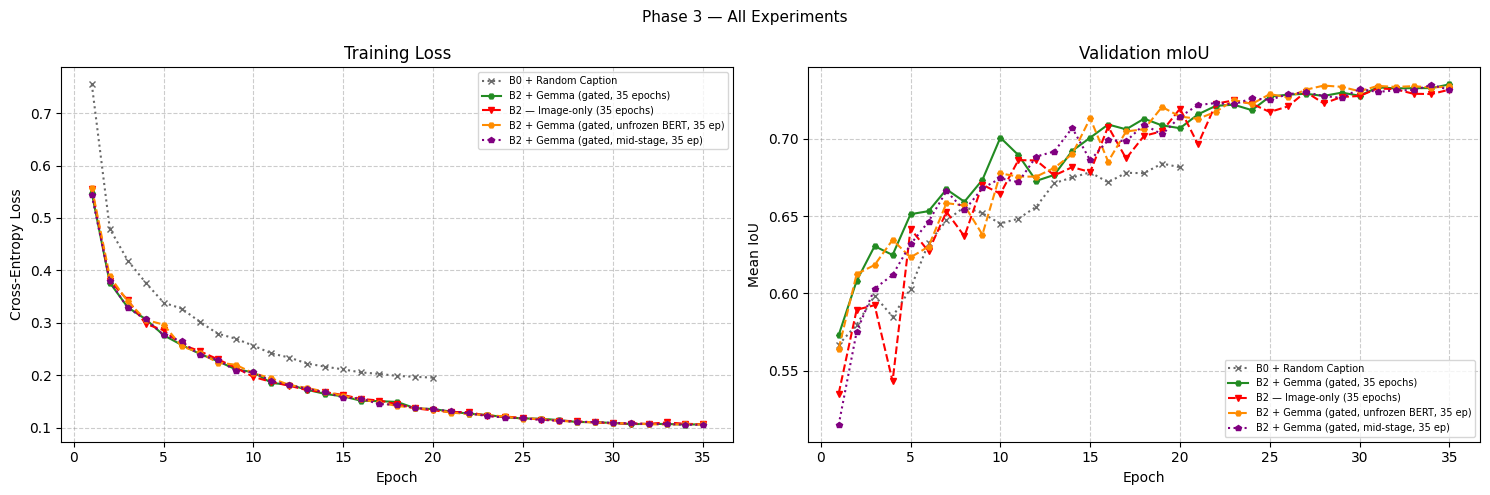


── Phase 3 Ablation Summary (B2, 35 epochs) ─────────────
  B2 image-only baseline (35 ep)            : 0.7439
  B2 + gated fusion, frozen BERT            : 0.7460  (Δ: +0.0021)
  B2 + gated fusion, unfrozen BERT          : 0.7427  (Δ vs baseline: -0.0012, Δ vs Exp10: -0.0033)
  B2 + gated fusion, mid-stage (H/16)       : 0.7397  (Δ vs baseline: -0.0042, Δ vs Exp10: -0.0063)

── Random Caption Ablation ──────────────────────────────
  B2 image-only baseline (35 ep) : 0.7439
  B0 + random captions           : 0.6861  (Δ: -0.0578)


In [47]:
STYLES = [
    ('x:',  'dimgray',         'B0 + Random Caption'),
    ('H-',  'forestgreen', 'B2 + Gemma (gated, 35 epochs)'),           # Exp 10
    ('v--', 'red', 'B2 — Image-only (35 epochs)'),              # Exp 11
    ('H--', 'darkorange',  'B2 + Gemma (gated, unfrozen BERT, 35 ep)'), # Exp 12
    ('p:',  'purple',      'B2 + Gemma (gated, mid-stage, 35 ep)'),     # Exp 13
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

for ax in (ax1, ax2):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')

for (style, color, label), res in zip(STYLES, all_results.values()):
    epochs = list(range(1, len(res['history']['train_loss']) + 1))
    ax1.plot(epochs, res['history']['train_loss'], style, color=color,
             lw=1.5, ms=4, label=label)
    ax2.plot(epochs, res['history']['val_miou'], style, color=color,
             lw=1.5, ms=4, label=label)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss'); ax1.legend(labelcolor='black', fontsize=7)
ax1.grid(True, linestyle='--', alpha=0.4, color='gray')

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Mean IoU')
ax2.set_title('Validation mIoU'); ax2.legend(labelcolor='black', fontsize=7)
ax2.grid(True, linestyle='--', alpha=0.4, color='gray')

fig.suptitle('Phase 3 — All Experiments', fontsize=11, color='black')
plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/phase3_training_curves.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── Phase 3 Ablation Summary ──────────────────────────────────────────────────
if 'exp10' in all_results and 'exp11' in all_results:
    b2_35 = all_results['exp11']['test_metrics']['miou']
    exp10 = all_results['exp10']['test_metrics']['miou']
    print('\n── Phase 3 Ablation Summary (B2, 35 epochs) ─────────────')
    print(f'  B2 image-only baseline (35 ep)            : {b2_35:.4f}')
    print(f'  B2 + gated fusion, frozen BERT            : {exp10:.4f}  (Δ: {exp10-b2_35:+.4f})')
    if 'exp12' in all_results:
        exp12 = all_results['exp12']['test_metrics']['miou']
        print(f'  B2 + gated fusion, unfrozen BERT          : {exp12:.4f}  (Δ vs baseline: {exp12-b2_35:+.4f}, Δ vs Exp10: {exp12-exp10:+.4f})')
    if 'exp13' in all_results:
        exp13 = all_results['exp13']['test_metrics']['miou']
        print(f'  B2 + gated fusion, mid-stage (H/16)       : {exp13:.4f}  (Δ vs baseline: {exp13-b2_35:+.4f}, Δ vs Exp10: {exp13-exp10:+.4f})')

# ── Random caption ablation ───────────────────────────────────────────────────
if 'fused_random' in all_results and 'exp11' in all_results:
    random_  = all_results['fused_random']['test_metrics']['miou']
    baseline = all_results['exp11']['test_metrics']['miou']
    print('\n── Random Caption Ablation ──────────────────────────────')
    print(f'  B2 image-only baseline (35 ep) : {baseline:.4f}')
    print(f'  B0 + random captions           : {random_:.4f}  (Δ: {random_-baseline:+.4f})')

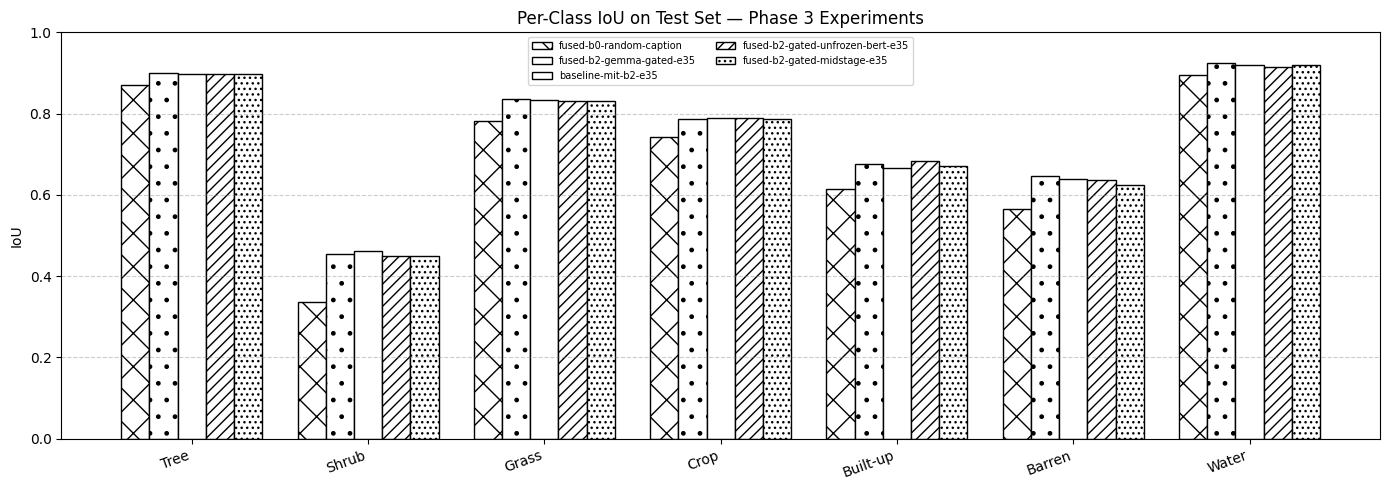

In [48]:
HATCHES = ['x', '.', '', '///', '...']

n_exps = len(all_results)
width  = 0.8 / n_exps

fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
ax.tick_params(colors='black')

x = np.arange(CONFIG['num_classes'])

for i, (res, hatch) in enumerate(zip(all_results.values(), HATCHES)):
    ious = [v if not np.isnan(v) else 0.0
            for v in res['test_metrics']['per_class_iou']]
    ax.bar(x + i * width, ious, width=width, label=res['run_name'],
           color='white', edgecolor='black', hatch=hatch)

ax.set_xticks(x + width * (n_exps - 1) / 2)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', color='black')
ax.set_ylabel('IoU', color='black')
ax.set_title('Per-Class IoU on Test Set — Phase 3 Experiments', color='black')
ax.legend(labelcolor='black', fontsize=7, ncol=2)
ax.grid(True, axis='y', linestyle='--', alpha=0.4, color='gray')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('results/figures/phase3_per_class_iou.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [49]:
# ── Rare-class Analysis: Does fusion disproportionately help Shrub, Barren & Built-up? ──
RARE_CLASSES = {1: "Shrub", 4: "Built-up", 5: "Barren"}

print(f"{"Experiment":<40} {"mIoU":>7}  {"Shrub IoU":>10}  {"Built-up IoU":>13}  {"Barren IoU":>11}  {"ΔShrub":>8}  {"ΔBuilt-up":>11}  {"ΔBarren":>9}")
print("-" * 120)

compare_keys = ["exp11", "exp10", "exp12", "exp13"]
baseline_iou = all_results["exp11"]["test_metrics"]["per_class_iou"]

for key in compare_keys:
    if key not in all_results:
        continue
    res     = all_results[key]
    pci     = res["test_metrics"]["per_class_iou"]
    miou    = res["test_metrics"]["miou"]  # lowercase — matches evaluate() return key
    shrub   = pci[1]
    builtup = pci[4]
    barren  = pci[5]
    d_shrub   = shrub   - baseline_iou[1]
    d_builtup = builtup - baseline_iou[4]
    d_barren  = barren  - baseline_iou[5]
    marker = "  <- baseline" if key == "exp11" else ""
    print(f"{res["run_name"]:<40} {miou:>7.4f}  {shrub:>10.4f}  {builtup:>13.4f}  {barren:>11.4f}  {d_shrub:>+8.4f}  {d_builtup:>+11.4f}  {d_barren:>+9.4f}{marker}")

print()
print("Delta = difference vs Exp 11 (B2 image-only baseline, 35 epochs)")
print("Positive delta = fusion helps that class more than the baseline")


Experiment                                  mIoU   Shrub IoU   Built-up IoU   Barren IoU    ΔShrub    ΔBuilt-up    ΔBarren
------------------------------------------------------------------------------------------------------------------------
baseline-mit-b2-e35                       0.7439      0.4617         0.6667       0.6394   +0.0000      +0.0000    +0.0000  <- baseline
fused-b2-gemma-gated-e35                  0.7460      0.4546         0.6761       0.6454   -0.0071      +0.0094    +0.0060
fused-b2-gated-unfrozen-bert-e35          0.7427      0.4485         0.6841       0.6354   -0.0132      +0.0174    -0.0040
fused-b2-gated-midstage-e35               0.7397      0.4501         0.6699       0.6241   -0.0116      +0.0032    -0.0153

Delta = difference vs Exp 11 (B2 image-only baseline, 35 epochs)
Positive delta = fusion helps that class more than the baseline


## Rare-Class Analysis (Shrub, Built-up, Barren)

Results show that fusion does not uniformly help all rare classes:

- **Built-up** consistently benefits from fusion across all models (+0.0094 for fused-b2-gemma-gated-e35, +0.0174 for fused-b2-gated-unfrozen-bert-e35). Captions likely mention roads and urban structures, providing a useful signal for this class.
- **Barren** shows mixed results — gated fusion helps slightly (+0.0060) but mid-stage injection hurts significantly (−0.0153), suggesting bare land features are sensitive to early-stage disruption.
- **Shrub** degrades across all fusion models (−0.0071 to −0.0132). Being spectrally similar to Grass and Tree, captions do not provide a discriminative enough signal and fusion adds noise instead.

Overall, the +0.0021 mIoU gain of fused-b2-gemma-gated-e35 is primarily driven by Built-up and Barren improvements, partially offset by Shrub degradation — text captions help most for structurally distinctive classes and least for spectrally ambiguous ones.

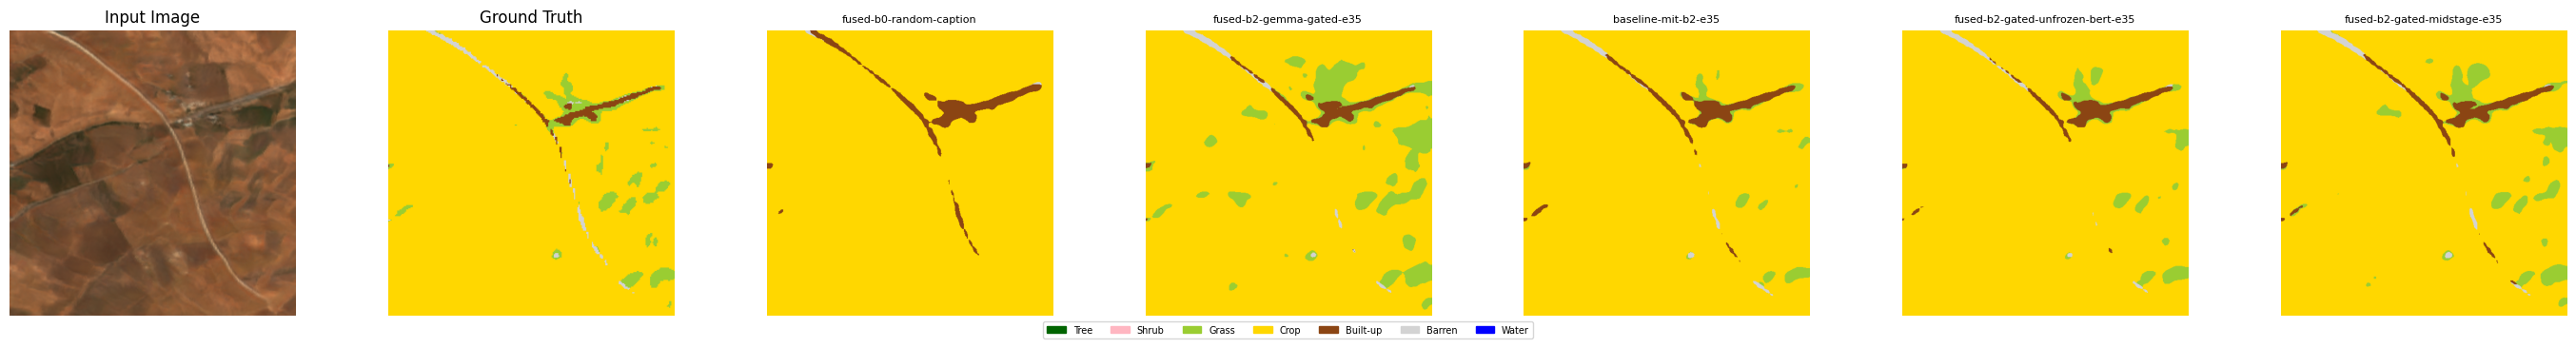

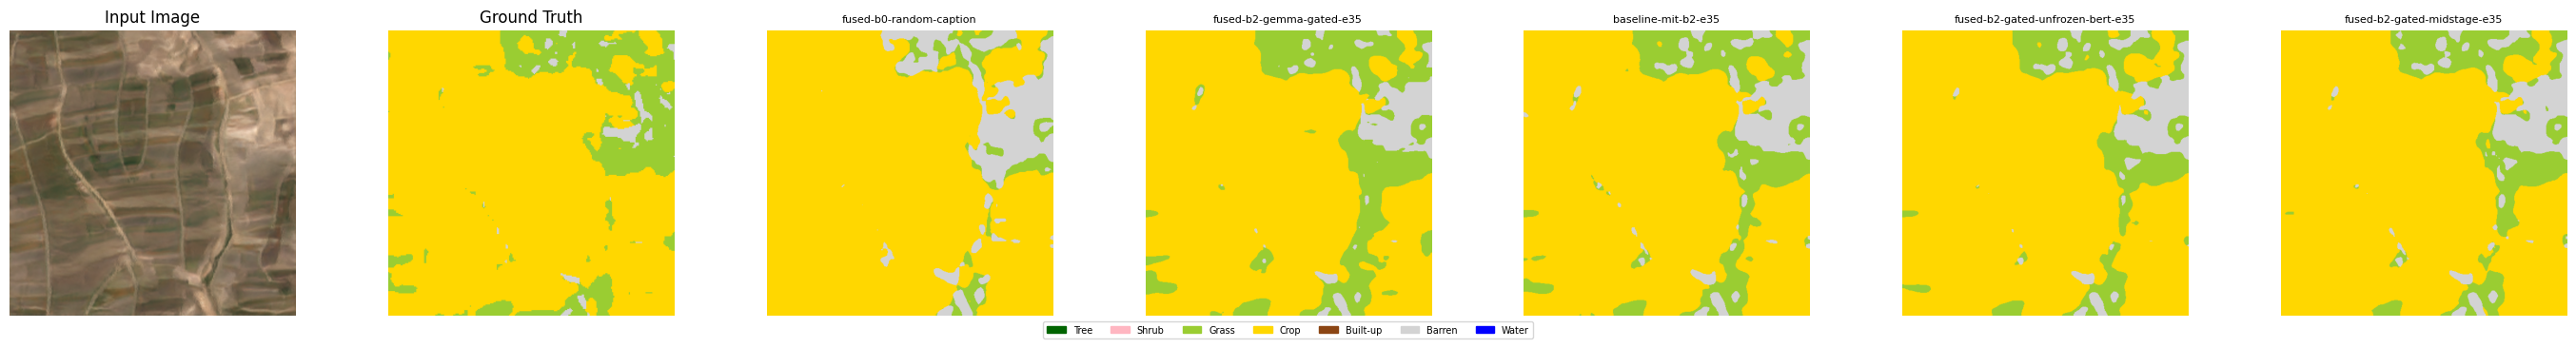

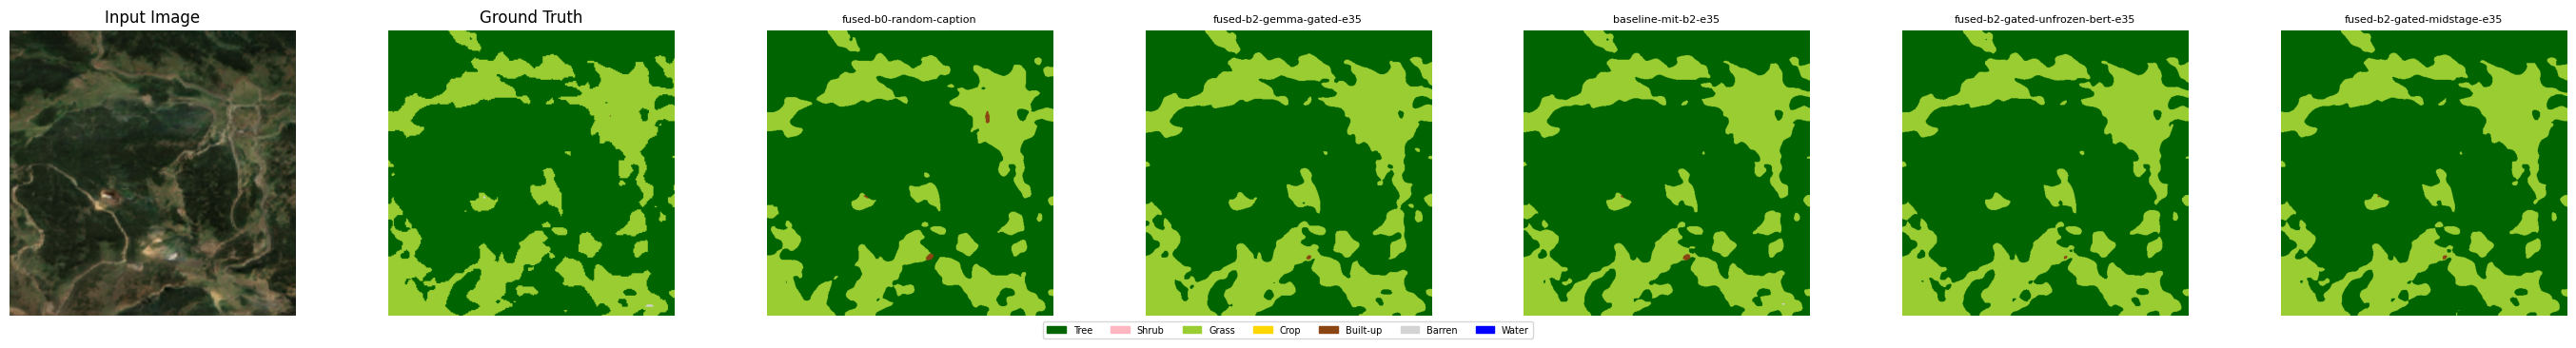

In [36]:
# I pick 3 samples that show different dominant land cover types via models
SAMPLE_INDICES = [0, len(val_df) // 2, len(val_df) - 1]

_, vl_base, _ = create_loaders(
    next(iter(all_results.values()))['config'],  # use any loaded config for image processing
    train_df, val_df, test_df, processor
)

for sample_idx in SAMPLE_INDICES:
    sample = vl_base.dataset[sample_idx]
    pv  = sample['pixel_values'].unsqueeze(0).to(device)
    lbl = sample['labels']

    fig, axes = plt.subplots(1, len(all_results) + 2,
                             figsize=(4 * (len(all_results) + 2), 3.5),
                             facecolor='white')

    # Input image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_np = ((sample['pixel_values'].cpu() * std + mean) * 255)\
             .permute(1,2,0).numpy().clip(0,255).astype(np.uint8)
    axes[0].imshow(img_np); axes[0].set_title('Input Image', color='black')

    # Ground truth
    axes[1].imshow(class_mask_to_rgb(lbl.numpy()))
    axes[1].set_title('Ground Truth', color='black')

    # Each model's prediction
    for ax, (key, res) in zip(axes[2:], all_results.items()):
        model = res['model'].to(device)
        model.eval()

        # Build caption loader from the config stored in the results file
        cfg = res['config']
        _, vl_exp, _ = create_loaders(cfg, train_df, val_df, test_df, processor)
        s_exp = vl_exp.dataset[sample_idx]
        cap = [s_exp['caption']] if 'caption' in s_exp else None

        with torch.no_grad():
            logits = model(pv, cap)
            up     = F.interpolate(logits, size=lbl.shape,
                                   mode='bilinear', align_corners=False)
            pred   = up.argmax(dim=1).squeeze(0).cpu()

        ax.imshow(class_mask_to_rgb(pred.numpy()))
        ax.set_title(res['run_name'], color='black', fontsize=8)

    for ax in axes:
        ax.axis('off')
        ax.set_facecolor('white')

    patches = [mpatches.Patch(color=np.array(CLASS_INFO[i]['color'])/255,
                               label=CLASS_INFO[i]['name'])
               for i in range(CONFIG['num_classes'])]
    fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=7,
               bbox_to_anchor=(0.5, -0.04), labelcolor='black')
    plt.tight_layout()
    plt.savefig(f'results/figures/phase3_pred_sample{sample_idx}.png',
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

### Qualitative Results of Images and Masks Above

Three validation samples covering distinct land cover compositions are shown.

**Row 1 (Crop + Built-up):** All B2 models correctly identify the dominant Crop regions and Built-up road structures. fused-b2-gemma-gated-e35 produces the sharpest Built-up boundaries, while fused-b2-gated-midstage-e35 loses the finest structural detail. The fused-b0-random-caption model adds noisy misclassifications around boundaries.

**Row 2 (Crop + Barren + Grass):** fused-b2-gemma-gated-e35 best captures the Barren (gray) patches alongside Crop regions. fused-b2-gated-midstage-e35 tends to over-predict Crop, under-representing the rarer Barren class — consistent with its lower per-class IoU. The fused-b0-random-caption model produces highly fragmented, inaccurate boundaries.

**Row 3 (Tree + Grass forest):** The most challenging scene — Tree and Grass are hard to distinguish due to their spectral similarity with human eye.

Overall, fused-b2-gemma-gated-e35 consistently yields the most precise boundaries across scenes, supporting its best quantitative result (mIoU = 0.7460). fused-b2-gated-midstage-e35 is the weakest B2 model qualitatively, losing fine structural detail — a consequence of mid-stage text injection disrupting spatial feature representations.

## Summary

## Phase 2 (Experiments 1–8)

The goal was to prove that adding text captions improves segmentation. Results showed **fusion did not consistently help**:

- **B0 and B1 architectures** showed negligible or negative fusion gains because smaller backbones have less representational capacity — the visual features are already compressed, leaving little room for text to add meaningful signal.
- **Random caption ablation (Exp 8)** confirmed that the model was not genuinely reading captions — shuffled captions from other images still produced similar (actually slightly worse: 0.6861) scores, meaning the fusion mechanism was not learning meaningful text-image alignment. So it proved the effect of the text in the fused version of model.

---

## Phase 3 (Experiments 9–13)

**Exp 9 — Failed attempt (B1 + mid-stage + unfrozen BERT):**
Tried two improvements at once: inject text at an earlier encoder stage (H/16) and unfreeze the last 2 BERT layers to adapt them to satellite imagery. It failed because a **single learning rate (4e-5) was applied to everything including BERT** — this was too aggressive for pretrained BERT weights, causing catastrophic forgetting of its language representations before it could adapt usefully.

---

**Exp 10 vs 11 — Gated fusion (the key Phase 3 contribution):**

The **gated fusion** mechanism adds a learnable scalar `alpha` initialized to 0:
* output = image_features + alpha × text_contribution

At the start of training, `alpha=0` means the model behaves as **pure image-only**. The gate opens gradually only when text genuinely helps — worst case it stays near 0 and matches the baseline, best case it grows positive and text improves predictions.

Results from the table and validation curve:
- **Exp 10** (gated fusion, 35 ep): **0.7460** — best overall
- **Exp 11** (image-only baseline, 35 ep): **0.7439**
- **Δ = +0.0021** — first clean positive fusion result across all experiments

The validation curve confirms Exp 10 consistently sits slightly above Exp 11 after epoch ~20 and converges higher.

---

**Exp 12 — Unfrozen BERT (Δ = −0.0012 vs baseline):**
Used separate learning rates (BERT: 1e-5, rest: 6e-5) to gently adapt BERT. Despite the fix, it **underperformed** Exp 10. The validation curve shows more instability early. Likely reason: adapting BERT to satellite imagery from a small dataset is insufficient — the domain gap between general language pretraining and remote sensing captions is too large to close in 35 epochs.

---

**Exp 13 — Mid-stage fusion (Δ = −0.0042 vs baseline):**
Injected text at stage 2 (H/16, 320 channels) instead of the last stage. **Worst result** of the Phase 3 ablations (0.7397). The validation curve shows a **severe dip in early epochs** — injecting text at H/16 disrupts the mid-level features that stage 3 relies on, pushing them outside their pretrained distribution. Even with the gate, the model takes much longer to recover.

---

**Per-class IoU observations:**
- **Shrub** is consistently the hardest class (~0.46 for B2 models) — likely rare and spectrally similar to Grass
- **Barren and Built-up** are moderate (~0.63–0.68), where fusion shows small gains in Exp 10
- **Tree, Grass, Crop, Water** are all high (0.79–0.93) across all models — easy to distinguish visually, text adds little
- All B2 models perform very similarly per-class, suggesting the +0.0021 mIoU gain from gated fusion is distributed across multiple classes rather than concentrated in one